## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregamento e Preparação

In [3]:
df = pd.read_csv('urldata_features_v2.csv')

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features utilizadas : {X.shape[1]}')
print(f'Treino              : {X_train.shape[0]:,} instancias (80%)')
print(f'Teste               : {X_test.shape[0]:,} instancias (20%)')
print(f'\nFeatures:')
for i, c in enumerate(X.columns, 1):
    print(f'  {i:>2}. {c}')

Features utilizadas : 27
Treino              : 76,728 instancias (80%)
Teste               : 19,183 instancias (20%)

Features:
   1. lex_comp_url
   2. lex_comp_dominio
   3. lex_comp_path
   4. lex_n_pontos
   5. lex_n_hifenes
   6. lex_n_subdominios
   7. lex_n_digitos
   8. lex_n_barras
   9. lex_n_iguais
  10. lex_n_ampersands
  11. lex_n_percent
  12. lex_n_underscores
  13. lex_n_params
  14. lex_ratio_digitos
  15. lex_ratio_especiais
  16. lex_profundidade
  17. lex_tem_https
  18. lex_tem_ip
  19. lex_tem_arroba
  20. lex_tem_http_no_path
  21. lex_tld_suspeito
  22. lex_encurtador
  23. lex_porto_suspeito
  24. lex_digitos_consecutivos
  25. lex_palavras_suspeitas
  26. lex_entropia_dominio
  27. lex_entropia_url


## 3. Treino do Modelo

In [4]:
modelo = RandomForestClassifier(
    n_estimators=500,       # melhor parametro encontrado no Passo 4
    max_features=0.5,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print('A treinar o modelo...')
modelo.fit(X_train, y_train)
print('Treino concluido!')

A treinar o modelo...
Treino concluido!


## 4. Avaliação

In [5]:
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('  METRICAS — MODELO LEXICAL (27 FEATURES)')
print('=' * 50)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  AUC-ROC   : {auc*100:.2f}%')
print('=' * 50)
print()
print(classification_report(y_test, y_pred,
      target_names=['Benigno (0)', 'Malicioso (1)']))

  METRICAS — MODELO LEXICAL (27 FEATURES)
  Accuracy  : 92.81%
  Precision : 95.03%
  Recall    : 90.34%
  F1-Score  : 92.62%
  AUC-ROC   : 97.65%

               precision    recall  f1-score   support

  Benigno (0)       0.91      0.95      0.93      9602
Malicioso (1)       0.95      0.90      0.93      9581

     accuracy                           0.93     19183
    macro avg       0.93      0.93      0.93     19183
 weighted avg       0.93      0.93      0.93     19183



## 5. Comparação com Modelo Original (21 features)

In [6]:
# Resultados do modelo original (Passo 4) para comparacao
modelo_original = {
    'Accuracy' : 0.9483, 'Precision': 0.9550,
    'Recall'   : 0.9409, 'F1-Score' : 0.9479, 'AUC-ROC': 0.9884
}
modelo_lexical = {
    'Accuracy' : acc, 'Precision': prec,
    'Recall'   : rec, 'F1-Score' : f1,   'AUC-ROC': auc
}

print(f'  {"Metrica":<12}  {"Original (21 feat)":>20}  {"Lexical (27 feat)":>19}  {"Diferenca":>11}')
print('  ' + '-' * 68)
for m in modelo_original:
    orig = modelo_original[m]
    lex  = modelo_lexical[m]
    diff = lex - orig
    sinal = '+' if diff >= 0 else ''
    print(f'  {m:<12}  {orig*100:>19.2f}%  {lex*100:>18.2f}%  {sinal}{diff*100:>9.2f}%')

  Metrica         Original (21 feat)    Lexical (27 feat)    Diferenca
  --------------------------------------------------------------------
  Accuracy                    94.83%               92.81%      -2.02%
  Precision                   95.50%               95.03%      -0.47%
  Recall                      94.09%               90.34%      -3.75%
  F1-Score                    94.79%               92.62%      -2.17%
  AUC-ROC                     98.84%               97.65%      -1.19%


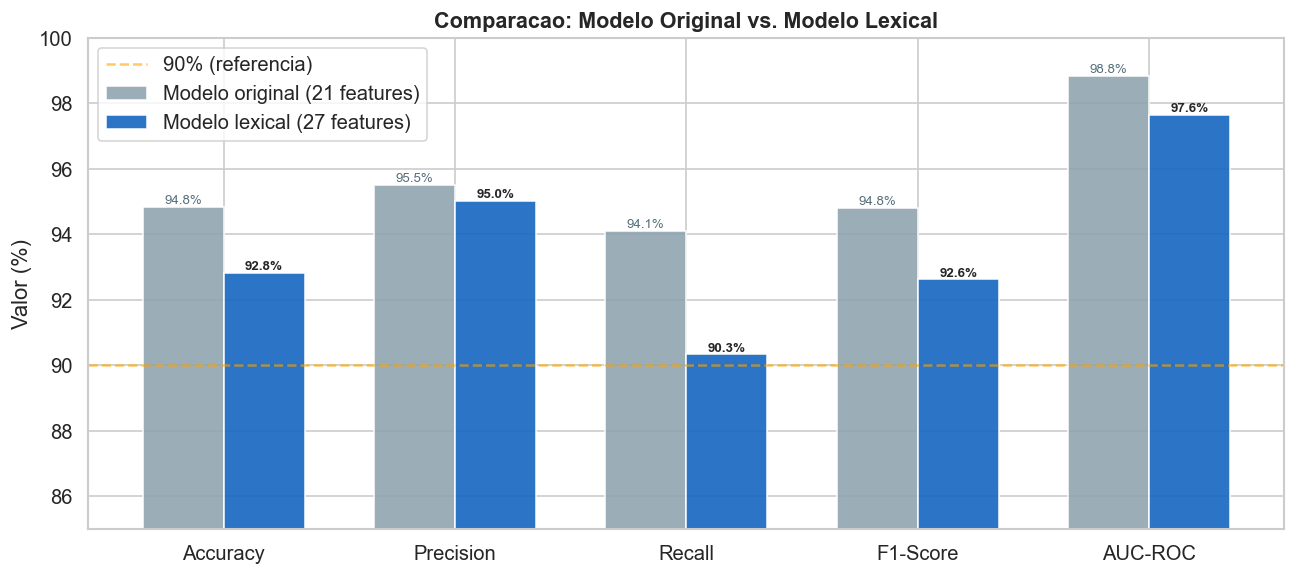

In [7]:
# Grafico comparativo
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
vals_orig = [modelo_original[m]*100 for m in metricas]
vals_lex  = [modelo_lexical[m]*100  for m in metricas]
x = range(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - largura/2 for i in x], vals_orig, largura,
       label='Modelo original (21 features)', color='#90a4ae', alpha=0.9)
ax.bar([i + largura/2 for i in x], vals_lex, largura,
       label='Modelo lexical (27 features)', color='#1565c0', alpha=0.9)
for i, (vo, vl) in enumerate(zip(vals_orig, vals_lex)):
    ax.text(i - largura/2, vo + 0.1, f'{vo:.1f}%', ha='center', fontsize=8, color='#546e7a')
    ax.text(i + largura/2, vl + 0.1, f'{vl:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.axhline(y=90, color='orange', linestyle='--', alpha=0.6, label='90% (referencia)')
ax.set_xticks(list(x))
ax.set_xticklabels(metricas)
ax.set_ylim(85, 100)
ax.set_ylabel('Valor (%)')
ax.set_title('Comparacao: Modelo Original vs. Modelo Lexical',
             fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig_comparacao_modelos_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Matriz de Confusão

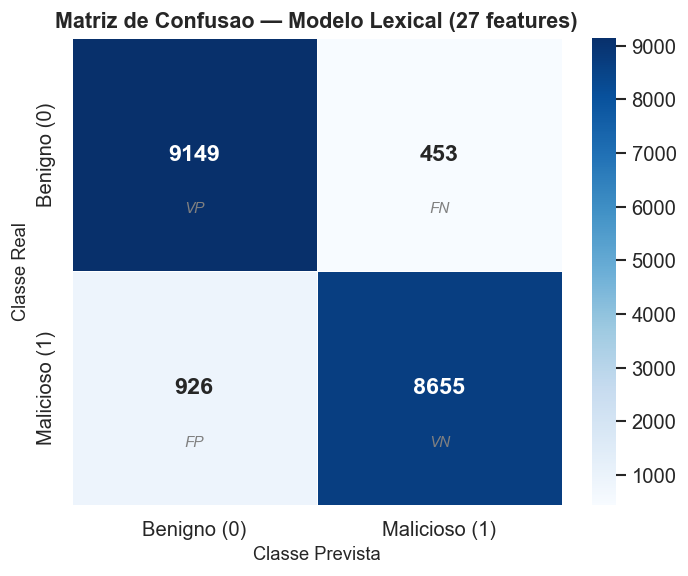

VP: 9,149  FN: 453
FP: 926  VN: 8,655

Falsos Positivos (URL maliciosos nao detetados): 926
Taxa FP: 9.66%


In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Malicioso (1)'],
            yticklabels=['Benigno (0)', 'Malicioso (1)'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Classe Prevista', fontsize=11)
ax.set_ylabel('Classe Real', fontsize=11)
ax.set_title('Matriz de Confusao — Modelo Lexical (27 features)',
             fontweight='bold', fontsize=13)
labels_cm = [['VP', 'FN'], ['FP', 'VN']]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.75, labels_cm[i][j], ha='center',
                fontsize=9, color='grey', style='italic')
plt.tight_layout()
plt.savefig('fig_confusao_modelo_lexical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'VP: {cm[0,0]:,}  FN: {cm[0,1]:,}')
print(f'FP: {cm[1,0]:,}  VN: {cm[1,1]:,}')
print(f'\nFalsos Positivos (URL maliciosos nao detetados): {cm[1,0]:,}')
print(f'Taxa FP: {cm[1,0]/(cm[1,0]+cm[1,1])*100:.2f}%')

## 7. Feature Importance

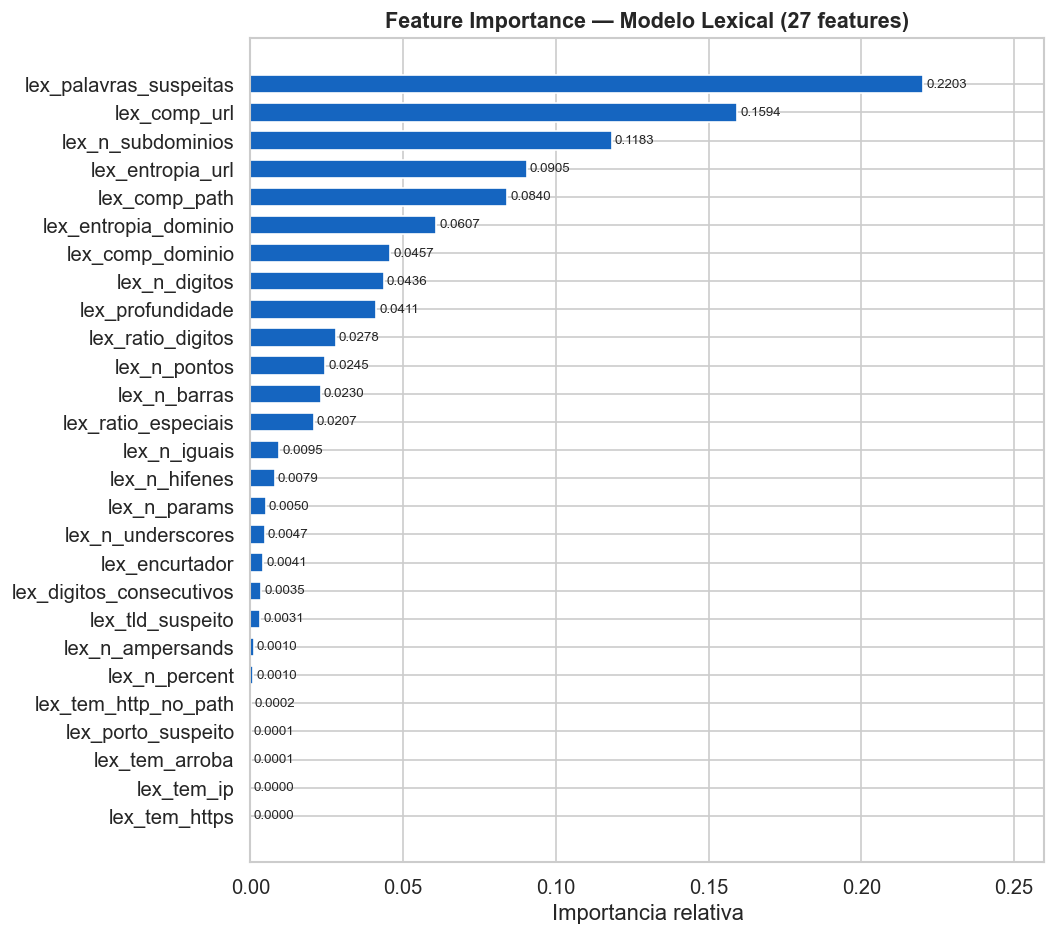

Top 10 features mais importantes:
  lex_palavras_suspeitas      : 0.2203  ████████████████████████████████████████████
  lex_comp_url                : 0.1594  ███████████████████████████████
  lex_n_subdominios           : 0.1183  ███████████████████████
  lex_entropia_url            : 0.0905  ██████████████████
  lex_comp_path               : 0.0840  ████████████████
  lex_entropia_dominio        : 0.0607  ████████████
  lex_comp_dominio            : 0.0457  █████████
  lex_n_digitos               : 0.0436  ████████
  lex_profundidade            : 0.0411  ████████
  lex_ratio_digitos           : 0.0278  █████


In [9]:
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
cores = ['#1565c0'] * len(importancias)
ax.barh(importancias.index, importancias.values,
        color=cores, edgecolor='white', height=0.65)
for i, (feat, val) in enumerate(importancias.items()):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
ax.set_title('Feature Importance — Modelo Lexical (27 features)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importancias.max() * 1.18)
plt.tight_layout()
plt.savefig('fig_importance_modelo_lexical.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features mais importantes:')
for feat, val in importancias.nlargest(10).items():
    barra = chr(9608) * int(val * 200)
    print(f'  {feat:<28}: {val:.4f}  {barra}')

## 8. Validação Cruzada

In [10]:
print('A executar validacao cruzada 5-Fold...')
scores_f1  = cross_val_score(modelo, X, y, cv=5, scoring='f1',       n_jobs=-1)
scores_acc = cross_val_score(modelo, X, y, cv=5, scoring='accuracy',  n_jobs=-1)
scores_auc = cross_val_score(modelo, X, y, cv=5, scoring='roc_auc',   n_jobs=-1)

print(f'\nValidacao Cruzada (5-Fold):')
print(f'  F1-Score : {scores_f1.mean()*100:.2f}%  (+-{scores_f1.std()*100:.2f}%)')
print(f'  Accuracy : {scores_acc.mean()*100:.2f}%  (+-{scores_acc.std()*100:.2f}%)')
print(f'  AUC-ROC  : {scores_auc.mean()*100:.2f}%  (+-{scores_auc.std()*100:.2f}%)')
print()
print('Scores individuais F1:')
for i, s in enumerate(scores_f1, 1):
    print(f'  Fold {i}: {s*100:.2f}%')

A executar validacao cruzada 5-Fold...

Validacao Cruzada (5-Fold):
  F1-Score : 90.95%  (+-1.26%)
  Accuracy : 91.16%  (+-1.17%)
  AUC-ROC  : 96.76%  (+-0.80%)

Scores individuais F1:
  Fold 1: 88.54%
  Fold 2: 91.44%
  Fold 3: 91.58%
  Fold 4: 91.01%
  Fold 5: 92.15%


## 9. Guardar Modelo

In [11]:
joblib.dump(modelo, 'modelo_rf_lexical.pkl')
print('Modelo guardado: modelo_rf_lexical.pkl')

m = joblib.load('modelo_rf_lexical.pkl')
print(f'Verificacao OK — {m.n_estimators} arvores, {m.n_features_in_} features')

Modelo guardado: modelo_rf_lexical.pkl
Verificacao OK — 500 arvores, 27 features


## 10. Resumo

In [12]:
print('=' * 55)
print('  RESUMO — MODELO LEXICAL (PASSO 3 v2)')
print('=' * 55)
print(f'  Algoritmo          : Random Forest (params otimizados)')
print(f'  Features           : 27 (apenas lexicais)')
print(f'  Treino             : {X_train.shape[0]:,} instancias')
print(f'  Teste              : {X_test.shape[0]:,} instancias')
print()
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print(f'  AUC-ROC   : {auc*100:.2f}%')
print()
print(f'  Modelo guardado    : modelo_rf_lexical.pkl')
print('=' * 55)
print('Proximo passo: Passo 6 — Atualizar aplicacao Flask')

  RESUMO — MODELO LEXICAL (PASSO 3 v2)
  Algoritmo          : Random Forest (params otimizados)
  Features           : 27 (apenas lexicais)
  Treino             : 76,728 instancias
  Teste              : 19,183 instancias

  Accuracy  : 92.81%
  Precision : 95.03%
  Recall    : 90.34%
  F1-Score  : 92.62%
  AUC-ROC   : 97.65%

  Modelo guardado    : modelo_rf_lexical.pkl
Proximo passo: Passo 6 — Atualizar aplicacao Flask
